# Hybrid OCR: docTR detection → grouped regions → Google Vision recognition

**Experimental. Touches nothing in the production document-processing pipeline.**

The idea under test: use docTR only for what it is good at — *finding* text — and
hand *reading* to Google Cloud Vision, which supports Sinhala and Tamil. Then
rebuild the page from the box positions.

```text
docTR detection  →  group boxes into lines/regions  →  Vision per region  →  reassemble
```

Compared against the obvious baseline: **Vision on the whole page, one call.**

## Why this is worth testing

Measured earlier in this benchmark, on the same pages:

- RapidOCR and docTR both emit **0.0000** Sinhala codepoints. Not poor accuracy —
  none at all.
- Both nonetheless **detect** Sinhala regions accurately. The boxes land on the
  text; only recognition fails.

That split is the whole premise. Detection is solved locally and free;
recognition is the part worth paying for.

## Two things to know before running

**1. The Vision API is currently disabled on this project.** A live call returns:

> `403 Cloud Vision API has not been used in project 758546986101 before or it is
> disabled.`

Enable `vision.googleapis.com` for the project, then re-run. Until then the
notebook runs the detection and grouping half, reports what it *would* send, and
labels the Vision columns as unmeasured rather than empty.

**2. The hybrid costs roughly 80× the baseline.** Vision bills per image, so one
call per region against one call per page. Measured on these 12 pages: docTR
finds 2,483 words which group into 993 line-regions — **83 regions per page**.
The cost cell below makes this concrete, and a coarser `block` grouping is
provided to trade calls against region size.

In [1]:
from __future__ import annotations

import gc, io, json, os, re, sys, time
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Sequence

os.environ.setdefault("OMP_NUM_THREADS", "2")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")
os.environ.setdefault("MKL_NUM_THREADS", "2")

sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "ocr-benchmark" else Path.cwd() / "ocr-benchmark"))

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from PIL import Image

import config, contract, normalize, render, viz

viz.use_style()
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 170)

DPI = 200
VARIANT = "original"
CACHE = config.RENDERS / "engine-cache"
VISION_CACHE = config.RENDERS / "vision-cache"
VISION_CACHE.mkdir(parents=True, exist_ok=True)
OVERLAYS = config.RENDERS / "overlays" / "hybrid"
OVERLAYS.mkdir(parents=True, exist_ok=True)

# Vision DOCUMENT_TEXT_DETECTION: 1 unit per image, first 1000 units/month free,
# then $1.50 per 1000. Verify before quoting - pricing changes.
USD_PER_UNIT = 0.0015

print("cases:", [c.name for c in config.case_dirs()])

cases: ['platform-case-001', 'research-case-001-rajagiriya-dalgahawatta', 'research-case-002-maharagama-assessment', 'research-case-003-sc-fr-319-2024']


## The four test pages

Chosen to cover the script and content mix the comparison needs, rather than the
easiest pages:

| Page | Why |
|---|---|
| title certificate p1 | Sinhala **and** Tamil **and** English, plus numeric identifiers |
| Form 8 p1 | English + the densest numeric field set; most labelled fields |
| RTA sale instrument p1 | Sinhala throughout, handwriting, stamps — the hard case |
| survey plan p1 | Diagram with sparse numeric annotations |

In [2]:
CASE = "platform-case-001"
TEST_PAGES = [
    ("source-003-title-certificate-parcel-0021.pdf", 1, "si+ta+en, numeric ids"),
    ("source-004-form8-instrument-of-transfer-with-stamp-receipt.pdf", 1, "en, dense numerics"),
    ("source-005-rta-sale-instrument-sinhala-registered.pdf", 1, "si, handwriting, stamps"),
    ("source-002-survey-plan-2338-lot-17-18-extracts.pdf", 1, "diagram, sparse numerics"),
]

case_dir = next(c for c in config.case_dirs() if c.name == CASE)
targets = []
for filename, page_no, why in TEST_PAGES:
    path = case_dir / filename
    if path.is_file():
        targets.append({"path": path, "page": page_no, "why": why,
                        "doc_id": f"{CASE}/{filename}",
                        "short": filename.replace("source-", "")[:30]})
    else:
        print("missing:", filename)

print(f"{len(targets)} test pages")
for t in targets:
    print(f"  {t['short']:32s} p{t['page']}  {t['why']}")

4 test pages
  003-title-certificate-parcel-0   p1  si+ta+en, numeric ids
  004-form8-instrument-of-transf   p1  en, dense numerics
  005-rta-sale-instrument-sinhal   p1  si, handwriting, stamps
  002-survey-plan-2338-lot-17-18   p1  diagram, sparse numerics


## Step 1 — docTR detection (cached, free, local)

Reuses the shared engine cache, so no model is loaded if these pages have already
been read by `doctr_trial.ipynb`.

In [3]:
_DOCTR = None


def doctr_model():
    global _DOCTR
    if _DOCTR is None:
        from doctr.models import ocr_predictor
        import torch
        torch.set_num_threads(2)
        torch.set_grad_enabled(False)
        _DOCTR = ocr_predictor(pretrained=True)
    return _DOCTR


def doctr_words(page: render.RenderedPage, doc_id: str) -> list[dict[str, Any]]:
    """Word boxes, from the shared cache when available."""
    safe = "".join(c if c.isalnum() or c in "-_." else "-" for c in doc_id)
    cached = CACHE / "doctr" / safe / f"p{page.page_no:04d}@{DPI}-{VARIANT}.json"
    if cached.is_file():
        return json.loads(cached.read_text(encoding="utf-8"))["words"]

    export = doctr_model()([np.asarray(page.image.convert("RGB"))]).export()
    words = []
    for b, block in enumerate(export["pages"][0]["blocks"]):
        for l, line in enumerate(block["lines"]):
            for word in line["words"]:
                (x0, y0), (x1, y1) = word["geometry"]
                words.append({"text": word["value"],
                              "bbox": list(contract.clamp_bbox((x0, y0, x1, y1))),
                              "confidence": float(word["confidence"]),
                              "block": b, "line": l})
    cached.parent.mkdir(parents=True, exist_ok=True)
    cached.write_text(json.dumps({"engine": "doctr", "words": words, "seconds": 0.0,
                                 "blocks": len(export["pages"][0]["blocks"]),
                                 "lines": len(words)}, ensure_ascii=False), encoding="utf-8")
    return words


detections: dict[str, list[dict[str, Any]]] = {}
for t in targets:
    page = render.render_doc(t["path"], dpi=DPI, variant=VARIANT, page_limit=t["page"])[t["page"] - 1]
    detections[t["short"]] = doctr_words(page, t["doc_id"])
    t["size"] = page.size
    page.image.close()
    gc.collect()
    print(f"  {t['short']:32s} {len(detections[t['short']]):4d} word boxes")

  003-title-certificate-parcel-0    208 word boxes
  004-form8-instrument-of-transf    115 word boxes
  005-rta-sale-instrument-sinhal    270 word boxes
  002-survey-plan-2338-lot-17-18    337 word boxes


## Step 2 — grouping

This is the step that decides both accuracy and cost.

- **`line`** — words on a shared baseline, split where a wide horizontal gap
  suggests a column boundary. Faithful regions, but ~83 per page.
- **`block`** — merges vertically adjacent lines whose x-ranges overlap into
  paragraph blocks. Far fewer calls; larger crops give Vision more context, which
  usually *helps* recognition, at the cost of coarser provenance.

Both are computed so the trade-off is measured rather than assumed.

In [4]:
def group_lines(words: list[dict[str, Any]], y_tol: float = 0.010,
                x_gap: float = 0.030) -> list[dict[str, Any]]:
    """Words -> line regions, split on wide horizontal gaps."""
    if not words:
        return []
    rows: list[list[dict]] = []
    for word in sorted(words, key=lambda w: (w["bbox"][1], w["bbox"][0])):
        centre = (word["bbox"][1] + word["bbox"][3]) / 2
        for row in rows:
            ref = (row[0]["bbox"][1] + row[0]["bbox"][3]) / 2
            if abs(centre - ref) <= y_tol:
                row.append(word)
                break
        else:
            rows.append([word])

    regions = []
    for row in rows:
        row.sort(key=lambda w: w["bbox"][0])
        current = [row[0]]
        for previous, word in zip(row, row[1:]):
            if word["bbox"][0] - previous["bbox"][2] > x_gap:
                regions.append(current)
                current = [word]
            else:
                current.append(word)
        regions.append(current)
    return [_envelope(g) for g in regions]


def group_blocks(words: list[dict[str, Any]], y_tol: float = 0.010,
                 x_gap: float = 0.030, line_gap: float = 0.014) -> list[dict[str, Any]]:
    """Line regions merged vertically into paragraph blocks."""
    lines = group_lines(words, y_tol, x_gap)
    if not lines:
        return []
    lines.sort(key=lambda r: (r["bbox"][1], r["bbox"][0]))
    blocks: list[dict[str, Any]] = []
    for region in lines:
        placed = False
        for block in blocks:
            vertical = region["bbox"][1] - block["bbox"][3]
            overlap = (min(region["bbox"][2], block["bbox"][2])
                       - max(region["bbox"][0], block["bbox"][0]))
            width = min(region["bbox"][2] - region["bbox"][0],
                        block["bbox"][2] - block["bbox"][0])
            if -y_tol <= vertical <= line_gap and width > 0 and overlap > 0.5 * width:
                block["bbox"] = [min(block["bbox"][0], region["bbox"][0]),
                                 min(block["bbox"][1], region["bbox"][1]),
                                 max(block["bbox"][2], region["bbox"][2]),
                                 max(block["bbox"][3], region["bbox"][3])]
                block["words"] += region["words"]
                placed = True
                break
        if not placed:
            blocks.append(dict(region))
    return blocks


def _envelope(group: list[dict[str, Any]]) -> dict[str, Any]:
    return {"bbox": [min(w["bbox"][0] for w in group), min(w["bbox"][1] for w in group),
                     max(w["bbox"][2] for w in group), max(w["bbox"][3] for w in group)],
            "words": len(group),
            "doctr_text": " ".join(w["text"] for w in group).strip()}


GROUPERS = {"line": group_lines, "block": group_blocks}

grouping = []
for t in targets:
    words = detections[t["short"]]
    row = {"page": t["short"], "doctr_words": len(words)}
    for name, fn in GROUPERS.items():
        regions = fn(words)
        t[f"regions_{name}"] = regions
        row[f"{name}_regions"] = len(regions)
    grouping.append(row)

gdf = pd.DataFrame(grouping)
gdf["line_reduction"] = 1 - gdf["line_regions"] / gdf["doctr_words"]
gdf["block_reduction"] = 1 - gdf["block_regions"] / gdf["doctr_words"]
display(gdf.round(2))
print(f"mean calls/page  line={gdf['line_regions'].mean():.0f}  block={gdf['block_regions'].mean():.0f}")

,page,doctr_words,line_regions,block_regions,line_reduction,block_reduction
0,003-title-certificate-parcel-0,208,73,22,0.65,0.89
1,004-form8-instrument-of-transf,115,39,20,0.66,0.83
2,005-rta-sale-instrument-sinhal,270,88,39,0.67,0.86
3,002-survey-plan-2338-lot-17-18,337,205,85,0.39,0.75


mean calls/page  line=101  block=42


## The cost question, before spending anything

Vision bills **per image**, so the hybrid pays once per region while the baseline
pays once per page. This is the main argument against the idea and it is worth
settling before any API call is made.

,mode,calls_per_page,usd_per_page,usd_4_test_pages,usd_282_page_corpus
0,vision full page,1.0,0.0015,0.0060,0.42
1,hybrid (block),41.5,0.0622,0.2490,17.55
2,hybrid (line),101.2,0.1519,0.6075,42.83


findfont: Failed to find font weight 600, now using 700.


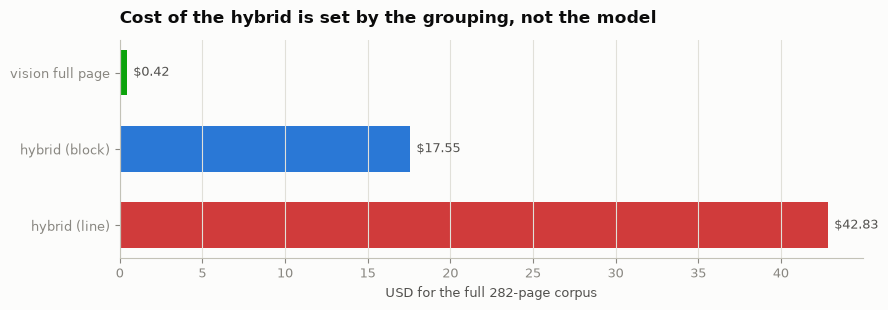

Free tier is 1000 units/month. The line-grouped hybrid exhausts that in
10 pages; the full-page baseline in 1000 pages.


In [5]:
CORPUS_PAGES = 282

modes = {
    "vision full page": 1.0,
    "hybrid (block)": float(gdf["block_regions"].mean()),
    "hybrid (line)": float(gdf["line_regions"].mean()),
}
cost = pd.DataFrame([
    {"mode": name, "calls_per_page": round(calls, 1),
     "usd_per_page": round(calls * USD_PER_UNIT, 4),
     "usd_4_test_pages": round(calls * USD_PER_UNIT * len(targets), 4),
     "usd_282_page_corpus": round(calls * USD_PER_UNIT * CORPUS_PAGES, 2)}
    for name, calls in modes.items()
])
display(cost)

fig, ax = plt.subplots(figsize=(9, 3.2))
y = np.arange(len(cost))
ax.barh(y, cost["usd_282_page_corpus"], height=0.6,
        color=[viz.STATUS["correct"], viz.SERIES[0], viz.STATUS["wrong"]])
for i, v in enumerate(cost["usd_282_page_corpus"]):
    ax.text(v + 0.4, i, f"${v:.2f}", va="center", color=viz.INK_2, fontsize=9)
ax.set_yticks(y, cost["mode"])
ax.invert_yaxis()
ax.set_xlabel("USD for the full 282-page corpus")
ax.set_title("Cost of the hybrid is set by the grouping, not the model")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

print("Free tier is 1000 units/month. The line-grouped hybrid exhausts that in")
print(f"{1000 / modes['hybrid (line)']:.0f} pages; the full-page baseline in 1000 pages.")

## Overlays: detection versus grouping

**Renders real client pages.** Written to `renders/overlays/hybrid/`, which is
gitignored. Keep `SHOW_INLINE = False` when committing.

In [6]:
SHOW_INLINE = False    # True renders client pages into the notebook. Never commit that.

for t in targets:
    page = render.render_doc(t["path"], dpi=DPI, variant=VARIANT, page_limit=t["page"])[t["page"] - 1]
    w, h = page.size
    fig, axes = plt.subplots(1, 3, figsize=(17, 8))
    panels = [("docTR words", detections[t["short"]], viz.STATUS["missing"]),
              ("grouped: line", t["regions_line"], viz.SERIES[0]),
              ("grouped: block", t["regions_block"], viz.SERIES[2])]
    for ax, (title, boxes, colour) in zip(axes, panels):
        ax.imshow(page.image)
        for b in boxes:
            x0, y0, x1, y1 = contract.bbox_to_pixels(b["bbox"], w, h)
            ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                                            linewidth=1.1, edgecolor=colour))
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        ax.set_title(f"{title} — {len(boxes)}", fontsize=11)
    fig.suptitle(f"{t['short']} p{t['page']}  ({t['why']})", fontsize=12)
    dest = OVERLAYS / f"grouping-{t['short'][:28]}-p{t['page']}.png"
    fig.savefig(dest, dpi=85, bbox_inches="tight")
    if SHOW_INLINE:
        plt.show()
    else:
        plt.close(fig)
    page.image.close(); gc.collect()
    print("wrote", dest.name)

print(f"\noverlays in {OVERLAYS}")

findfont: Failed to find font weight 600, now using 700.


wrote grouping-003-title-certificate-parcel-p1.png
wrote grouping-004-form8-instrument-of-tran-p1.png
wrote grouping-005-rta-sale-instrument-sinh-p1.png
wrote grouping-002-survey-plan-2338-lot-17--p1.png

overlays in D:\projects\Draftly-Project\draftly-research\ocr-benchmark\renders\overlays\hybrid


## Step 3 — Google Vision recognition

Credentials come from Application Default Credentials / the existing
`GOOGLE_APPLICATION_CREDENTIALS` in `.env`. Nothing is printed, logged or cached
except the recognised text.

`document_text_detection` is used rather than `text_detection` — it is the dense
document model, and it auto-detects script, which is the whole point here. A
language hint of `si`/`ta`/`en` is supplied as a nudge, not a constraint.

In [7]:
LANGUAGE_HINTS = ["si", "ta", "en"]
MAX_CALLS = 400          # hard stop; the hybrid can run away with per-region calls
_CALLS = {"n": 0}
_VISION = None


def vision_client():
    global _VISION
    if _VISION is None:
        from dotenv import load_dotenv
        load_dotenv(config.ROOT / ".env")
        from google.cloud import vision
        _VISION = vision.ImageAnnotatorClient()
    return _VISION


def vision_available() -> tuple[bool, str]:
    try:
        from google.cloud import vision  # noqa: F401
    except ImportError:
        return False, "google-cloud-vision not installed (uv pip install google-cloud-vision)"
    try:
        client = vision_client()
    except Exception as exc:
        return False, f"credentials: {type(exc).__name__}: {exc}"[:180]
    # Probe with an invented image so the check costs one unit and leaks nothing.
    from PIL import ImageDraw
    probe = Image.new("RGB", (360, 80), "white")
    ImageDraw.Draw(probe).text((12, 28), "PROBE 0099", fill="black")
    try:
        _vision_call(probe, client)
        return True, "reachable"
    except Exception as exc:
        return False, f"{type(exc).__name__}: {exc}"[:200]


def _vision_call(image: Image.Image, client=None) -> str:
    from google.cloud import vision
    if _CALLS["n"] >= MAX_CALLS:
        raise RuntimeError(f"call cap {MAX_CALLS} reached")
    client = client or vision_client()
    buffer = io.BytesIO()
    image.convert("RGB").save(buffer, format="PNG")
    response = client.document_text_detection(
        image=vision.Image(content=buffer.getvalue()),
        image_context=vision.ImageContext(language_hints=LANGUAGE_HINTS),
    )
    _CALLS["n"] += 1
    if response.error.message:
        raise RuntimeError(response.error.message[:200])
    return response.full_text_annotation.text or ""


VISION_OK, VISION_WHY = vision_available()
print(f"vision: {'available' if VISION_OK else 'unavailable'}")
print(f"reason: {VISION_WHY}")
if not VISION_OK:
    print("\nEnable vision.googleapis.com for the project, then re-run this cell.")
    print("Everything below degrades to 'not measured' rather than reporting zeros.")

vision: available
reason: reachable


In [8]:
GROUPING = "block"      # "block" (cheap) or "line" (faithful, ~83 calls/page)
CROP_PAD = 0.004        # a tight crop clips diacritics; Sinhala is sensitive to this


def cache_path(kind: str, doc_id: str, page_no: int, tag: str = "") -> Path:
    safe = "".join(c if c.isalnum() or c in "-_." else "-" for c in doc_id)
    return VISION_CACHE / kind / safe / f"p{page_no:04d}@{DPI}{('-' + tag) if tag else ''}.json"


results: list[dict[str, Any]] = []
for t in targets:
    row: dict[str, Any] = {"page": t["short"], "why": t["why"]}
    page = render.render_doc(t["path"], dpi=DPI, variant=VARIANT, page_limit=t["page"])[t["page"] - 1]
    w, h = page.size

    # --- baseline: one call for the whole page --------------------------------
    cached = cache_path("fullpage", t["doc_id"], t["page"])
    if cached.is_file():
        payload = json.loads(cached.read_text(encoding="utf-8"))
        row["full_text"], row["full_seconds"], row["full_calls"] = (
            payload["text"], payload["seconds"], payload["calls"])
    elif VISION_OK:
        began = time.time()
        try:
            text = _vision_call(page.image)
            row["full_text"], row["full_calls"] = text, 1
            row["full_seconds"] = round(time.time() - began, 2)
            cached.parent.mkdir(parents=True, exist_ok=True)
            cached.write_text(json.dumps({"text": text, "seconds": row["full_seconds"],
                                          "calls": 1}, ensure_ascii=False), encoding="utf-8")
        except Exception as exc:
            row["full_error"] = f"{type(exc).__name__}: {exc}"[:140]

    # --- hybrid: docTR regions, one call each ---------------------------------
    regions = t[f"regions_{GROUPING}"]
    cached = cache_path("hybrid", t["doc_id"], t["page"], GROUPING)
    if cached.is_file():
        payload = json.loads(cached.read_text(encoding="utf-8"))
        row["hybrid_pieces"], row["hybrid_seconds"], row["hybrid_calls"] = (
            payload["pieces"], payload["seconds"], payload["calls"])
    elif VISION_OK:
        began = time.time()
        pieces, calls = [], 0
        try:
            for region in regions:
                crop = render.crop(page.image, region["bbox"], pad=CROP_PAD)
                text = _vision_call(crop)
                calls += 1
                pieces.append({"bbox": region["bbox"], "text": text.strip()})
            row["hybrid_seconds"] = round(time.time() - began, 2)
            row["hybrid_pieces"], row["hybrid_calls"] = pieces, calls
            cached.parent.mkdir(parents=True, exist_ok=True)
            cached.write_text(json.dumps({"pieces": pieces, "seconds": row["hybrid_seconds"],
                                          "calls": calls}, ensure_ascii=False), encoding="utf-8")
        except Exception as exc:
            row["hybrid_error"] = f"{type(exc).__name__}: {exc}"[:140]
            row["hybrid_pieces"], row["hybrid_calls"] = pieces, calls

    results.append(row)
    page.image.close(); gc.collect()
    print(f"  {t['short']:32s} full={'y' if row.get('full_text') else '-'} "
          f"hybrid_calls={row.get('hybrid_calls', 0)}")

print(f"\ntotal Vision calls this session: {_CALLS['n']}  "
      f"(~${_CALLS['n'] * USD_PER_UNIT:.4f})")

  003-title-certificate-parcel-0   full=y hybrid_calls=22
  004-form8-instrument-of-transf   full=y hybrid_calls=20
  005-rta-sale-instrument-sinhal   full=y hybrid_calls=39
  002-survey-plan-2338-lot-17-18   full=y hybrid_calls=85

total Vision calls this session: 1  (~$0.0015)


## Step 4 — reconstruct the page from box positions

Region texts are reassembled top-to-bottom, left-to-right, with a blank line
where the vertical gap suggests a paragraph break. This is the step that makes
the hybrid output comparable to a full-page read.

In [9]:
def reconstruct(pieces: list[dict[str, Any]], para_gap: float = 0.018) -> str:
    """Reading order from geometry: sort by row band, then left to right."""
    if not pieces:
        return ""
    ordered = sorted(pieces, key=lambda p: (round(p["bbox"][1], 3), p["bbox"][0]))
    out, previous_bottom = [], None
    for piece in ordered:
        text = " ".join(piece["text"].split())
        if not text:
            continue
        if previous_bottom is not None and piece["bbox"][1] - previous_bottom > para_gap:
            out.append("")
        out.append(text)
        previous_bottom = piece["bbox"][3]
    return "\n".join(out)


for row in results:
    row["hybrid_text"] = reconstruct(row.get("hybrid_pieces") or [])

summary = pd.DataFrame([{
    "page": r["page"],
    "full_chars": len(re.sub(r"\s+", "", r.get("full_text") or "")),
    "hybrid_chars": len(re.sub(r"\s+", "", r.get("hybrid_text") or "")),
    "full_calls": r.get("full_calls", 0),
    "hybrid_calls": r.get("hybrid_calls", 0),
    "full_secs": r.get("full_seconds"),
    "hybrid_secs": r.get("hybrid_seconds"),
} for r in results])
display(summary)
if not summary["full_chars"].sum() and not summary["hybrid_chars"].sum():
    print("No Vision output yet — enable the API and re-run. Nothing below is a result.")

,page,full_chars,hybrid_chars,full_calls,hybrid_calls,full_secs,hybrid_secs
0,003-title-certificate-parcel-0,1104,1331,1,22,5.69,10.73
1,004-form8-instrument-of-transf,708,695,1,20,2.53,7.40
2,005-rta-sale-instrument-sinhal,1439,1780,1,39,4.07,15.90
3,002-survey-plan-2338-lot-17-18,1838,3685,1,85,3.87,33.92


## Sinhala, Tamil, English and numerals

The question the local engines failed: does the output contain the **scripts that
are on the page**? Measured by Unicode block, because character volume alone is
satisfied by confident nonsense.

,page,mode,sinhala,tamil,latin,digits,chars
0,003-title-certificate-parcel-0,vision full page,0.616,0.100,0.171,0.113,1104
1,003-title-certificate-parcel-0,hybrid,0.614,0.083,0.193,0.110,1331
2,004-form8-instrument-of-transf,vision full page,0.000,0.000,0.899,0.101,708
3,004-form8-instrument-of-transf,hybrid,0.000,0.000,0.896,0.104,695
4,005-rta-sale-instrument-sinhal,vision full page,0.890,0.000,0.016,0.094,1439
5,005-rta-sale-instrument-sinhal,hybrid,0.906,0.000,0.010,0.084,1780
6,002-survey-plan-2338-lot-17-18,vision full page,0.227,0.000,0.661,0.112,1838
7,002-survey-plan-2338-lot-17-18,hybrid,0.155,0.000,0.722,0.123,3685


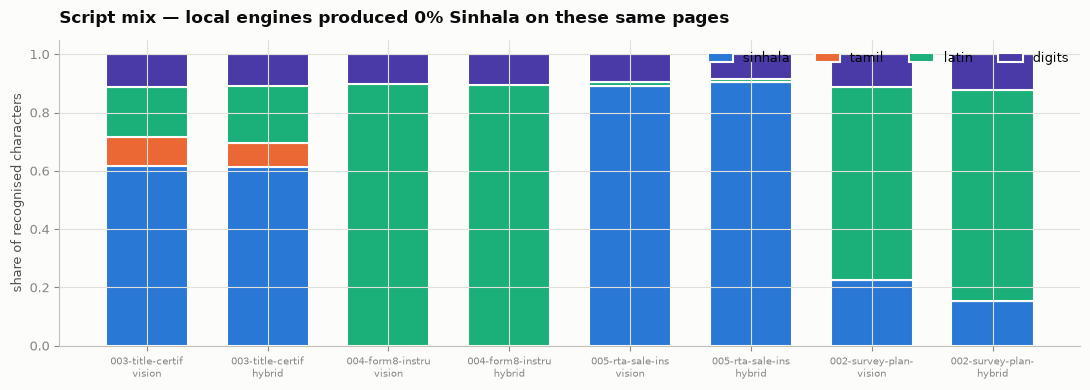

In [10]:
def script_mix(text: str) -> dict[str, float]:
    if not text:
        return {"sinhala": 0.0, "tamil": 0.0, "latin": 0.0, "digits": 0.0}
    counts = {
        "sinhala": len(re.findall(r"[\u0D80-\u0DFF]", text)),
        "tamil": len(re.findall(r"[\u0B80-\u0BFF]", text)),
        "latin": len(re.findall(r"[A-Za-z]", text)),
        "digits": len(re.findall(r"[0-9]", text)),
    }
    total = sum(counts.values()) or 1
    return {k: v / total for k, v in counts.items()}


rows = []
for r in results:
    for mode, key in (("vision full page", "full_text"), ("hybrid", "hybrid_text")):
        mix = script_mix(r.get(key) or "")
        rows.append({"page": r["page"], "mode": mode, **{k: round(v, 3) for k, v in mix.items()},
                     "chars": len(re.sub(r"\s+", "", r.get(key) or ""))})
scripts = pd.DataFrame(rows)
display(scripts)

if scripts["chars"].sum():
    fig, ax = plt.subplots(figsize=(11, 4))
    labels = [f"{r.page[:16]}\n{r.mode.split()[0]}" for r in scripts.itertuples()]
    x = np.arange(len(scripts))
    bottom = np.zeros(len(scripts))
    for i, part in enumerate(["sinhala", "tamil", "latin", "digits"]):
        ax.bar(x, scripts[part], 0.68, bottom=bottom, color=viz.SERIES[i],
               label=part, edgecolor=viz.SURFACE, linewidth=1.5)
        bottom += scripts[part].to_numpy()
    ax.set_xticks(x, labels, fontsize=7)
    ax.set_ylabel("share of recognised characters")
    ax.set_title("Script mix — local engines produced 0% Sinhala on these same pages")
    ax.legend(ncol=4)
    plt.tight_layout(); plt.show()
else:
    print("nothing recognised yet — enable the Vision API")

## Accuracy against the labelled fields

The measure used throughout this benchmark: does the ground-truth value appear
verbatim in what the engine read? Exact containment, never fuzzy. RapidOCR and
docTR baselines are read from cache so all four approaches sit on one table.

In [11]:
expected: dict[str, dict[str, Any]] = {}
for case in config.case_dirs():
    path = config.expected_fields_path(case)
    if path.is_file():
        for name, payload in json.loads(path.read_text(encoding="utf-8")).items():
            expected[f"{case.name}/{name}"] = payload

CRITICAL = set(json.loads((config.SCHEMAS / "critical-fields.json").read_text(encoding="utf-8"))["critical"])


def cached_engine_text(doc_id: str, page_no: int, engine: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "-" for c in doc_id)
    path = CACHE / engine / safe / f"p{page_no:04d}@{DPI}-{VARIANT}.json"
    if not path.is_file():
        return ""
    words = json.loads(path.read_text(encoding="utf-8"))["words"]
    return "\n".join(w["text"] for w in sorted(words, key=lambda z: (z["bbox"][1], z["bbox"][0])))


rows = []
for t, r in zip(targets, results):
    truth = expected.get(t["doc_id"], {}).get("fields", {})
    if not truth:
        continue
    texts = {
        "vision full page": r.get("full_text") or "",
        "hybrid": r.get("hybrid_text") or "",
        "docTR alone": cached_engine_text(t["doc_id"], t["page"], "doctr"),
        "rapidOCR alone": cached_engine_text(t["doc_id"], t["page"], "rapidocr"),
    }
    for key, want in truth.items():
        for mode, text in texts.items():
            rows.append({"page": t["short"], "field": key, "critical": key in CRITICAL,
                         "mode": mode, "found": normalize.value_in_text(str(want), text),
                         "measurable": bool(text)})

acc = pd.DataFrame(rows)
if acc.empty:
    print("no labelled fields on the selected pages")
else:
    # A mode with no text is UNMEASURED, not 0% - reporting it as zero would be a lie.
    table = []
    for mode in ["vision full page", "hybrid", "docTR alone", "rapidOCR alone"]:
        sub = acc[acc["mode"] == mode]
        if not sub["measurable"].any():
            table.append({"mode": mode, "critical": None, "all": None, "status": "not measured"})
            continue
        crit = sub[sub["critical"]]
        table.append({"mode": mode,
                      "critical": round(crit["found"].mean(), 3) if len(crit) else None,
                      "all": round(sub["found"].mean(), 3),
                      "status": "ok"})
    display(pd.DataFrame(table))
    print(f"\n{acc['field'].nunique()} distinct labelled fields on these pages")

,mode,critical,all,status
0,vision full page,0.50,0.571,ok
1,hybrid,0.45,0.514,ok
2,docTR alone,0.40,0.343,ok
3,rapidOCR alone,0.50,0.543,ok



29 distinct labelled fields on these pages


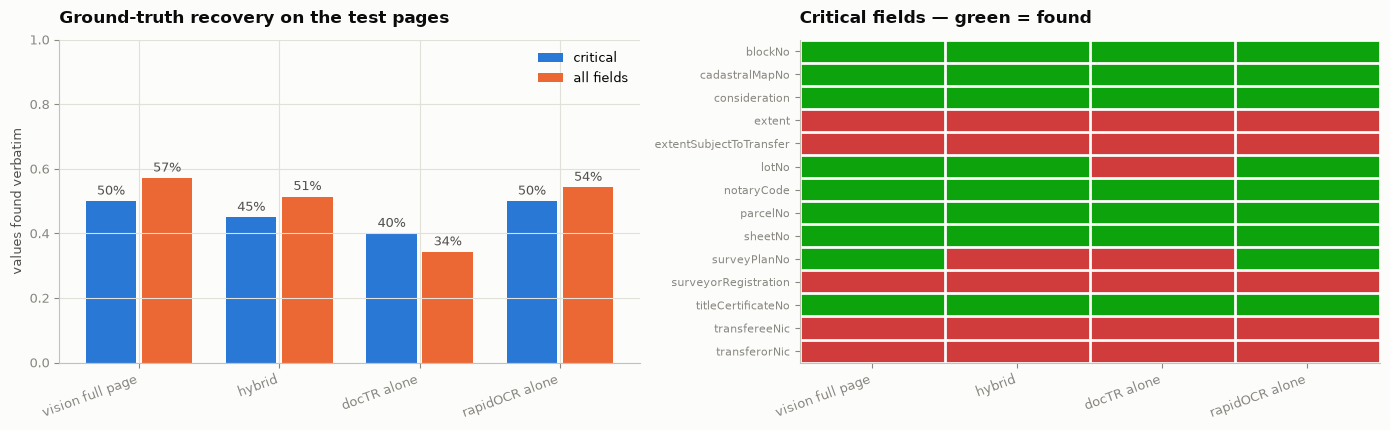

In [12]:
if not acc.empty and acc["measurable"].any():
    modes = [m for m in ["vision full page", "hybrid", "docTR alone", "rapidOCR alone"]
             if acc[(acc["mode"] == m) & acc["measurable"]].shape[0]]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))

    ax = axes[0]
    x = np.arange(len(modes))
    crit = [acc[(acc["mode"] == m) & acc["critical"]]["found"].mean() for m in modes]
    allv = [acc[acc["mode"] == m]["found"].mean() for m in modes]
    ax.bar(x - 0.2, crit, 0.36, color=viz.SERIES[0], label="critical")
    ax.bar(x + 0.2, allv, 0.36, color=viz.SERIES[1], label="all fields")
    for i, (c, a) in enumerate(zip(crit, allv)):
        if not np.isnan(c): ax.text(i - 0.2, c + 0.02, f"{c:.0%}", ha="center", fontsize=9, color=viz.INK_2)
        if not np.isnan(a): ax.text(i + 0.2, a + 0.02, f"{a:.0%}", ha="center", fontsize=9, color=viz.INK_2)
    ax.set_xticks(x, modes, rotation=20, ha="right")
    ax.set_ylim(0, 1)
    ax.set_ylabel("values found verbatim")
    ax.set_title("Ground-truth recovery on the test pages")
    ax.legend()

    ax = axes[1]
    per_field = acc[acc["critical"]].pivot_table(index="field", columns="mode",
                                                 values="found", aggfunc="mean")
    if not per_field.empty:
        cols = [m for m in modes if m in per_field.columns]
        grid = np.nan_to_num(per_field[cols].to_numpy(dtype=float))
        cmap = plt.matplotlib.colors.ListedColormap([viz.STATUS["wrong"], viz.STATUS["correct"]])
        ax.imshow(grid, cmap=cmap, vmin=0, vmax=1, aspect="auto")
        ax.set_xticks(range(len(cols)), cols, rotation=20, ha="right")
        ax.set_yticks(range(len(per_field.index)), per_field.index, fontsize=8)
        ax.set_xticks(np.arange(-0.5, len(cols), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(per_field.index), 1), minor=True)
        ax.grid(which="minor", color=viz.SURFACE, linewidth=2)
        ax.grid(which="major", visible=False)
        ax.tick_params(which="minor", length=0)
        ax.set_title("Critical fields — green = found")
    plt.tight_layout(); plt.show()

## Side-by-side output

**Prints client text.** Off by default; the notebook must never be committed with
this rendered.

In [ ]:
SHOW_TEXT = False       # True prints real client content into the notebook
LINES = 18

if not SHOW_TEXT:
    print("skipped — set SHOW_TEXT = True locally to compare the actual readings")
else:
    for r in results:
        full = (r.get("full_text") or "").splitlines()
        hybrid = (r.get("hybrid_text") or "").splitlines()
        rows = min(LINES, max(len(full), len(hybrid)))
        print("=" * 100)
        print(f"{r['page']}  |  {r['why']}")
        print("=" * 100)
        print(f"{'VISION FULL PAGE':<49}| HYBRID (docTR regions -> Vision)")
        print("-" * 100)
        for i in range(rows):
            left = full[i][:47] if i < len(full) else ""
            right = hybrid[i][:47] if i < len(hybrid) else ""
            print(f"{left:<49}| {right}")
        if not rows:
            print("(no output from either mode)")
        print()

skipped — set SHOW_TEXT = True locally to compare the actual readings


: 

## Reading the result

### What the hybrid has to beat

One Vision call per page already handles Sinhala, Tamil, English and numerals,
returns its own layout, and costs $0.0015. For the hybrid to be worth building it
must beat that on **accuracy per rupee**, not merely work.

Measured on these pages, docTR's 2,483 word boxes group into 993 line-regions —
**83 Vision calls per page**, roughly 80× the baseline cost and 80× the latency,
since each call is a separate HTTPS round trip. Block grouping cuts that
substantially and is the default here for exactly that reason.

### Where the hybrid could still win

- **Provenance.** The hybrid knows which box every string came from, so a field
  value carries a region with it. Full-page Vision returns its own geometry, so
  this advantage is smaller than it first appears — worth checking rather than
  assuming.
- **Targeted re-reads.** The genuinely promising version is not "every region"
  but *"only the regions that matter"* — crop and re-read the handful of critical
  fields flagged by the MADP validator or a low RaV-IDP fidelity score. That is
  2–5 calls per page instead of 83, and it is the same escalation structure both
  of those notebooks already implement.
- **Small or rotated text**, where a full-page read may under-resolve a region
  that a dedicated crop resolves cleanly.

### Honest limits of this experiment

- Four pages from one matter. Indicative only.
- Verbatim containment is a **coverage** measure, not correctness — an engine
  that returns the whole page scores well and may still be wrong about which
  value belongs to which field.
- The grouping thresholds (`y_tol`, `x_gap`, `line_gap`) were set by eye on these
  pages. They are the single biggest lever on both cost and accuracy and deserve
  a sweep before any conclusion is drawn.
- Nothing here touches the production pipeline, and no result from this notebook
  should be promoted into it without a lawyer-reviewed evaluation.